In [ ]:
# Credit Card Fraud Detection Using Machine Learning

In [31]:
# Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
#Load the Dataset
df = pd.read_csv("creditcard.csv")

In [3]:
#Display First Five Records
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [4]:
#Check Dataset Dimensions
df.shape

(160580, 31)

In [5]:
# Display Column Names
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160580 entries, 0 to 160579
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    160580 non-null  float64
 1   V1      160580 non-null  float64
 2   V2      160580 non-null  float64
 3   V3      160580 non-null  float64
 4   V4      160580 non-null  float64
 5   V5      160580 non-null  float64
 6   V6      160580 non-null  float64
 7   V7      160580 non-null  float64
 8   V8      160580 non-null  float64
 9   V9      160580 non-null  float64
 10  V10     160579 non-null  float64
 11  V11     160579 non-null  float64
 12  V12     160579 non-null  float64
 13  V13     160579 non-null  float64
 14  V14     160579 non-null  float64
 15  V15     160579 non-null  float64
 16  V16     160579 non-null  float64
 17  V17     160579 non-null  float64
 18  V18     160579 non-null  float64
 19  V19     160579 non-null  float64
 20  V20     160579 non-null  float64
 21  V21     16

In [7]:
#Statistical summary
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,160580.000000,160580.000000,160580.000000,160580.000000,160580.000000,160580.000000,160580.000000,160580.000000,160580.000000,160580.000000,...,160579.000000,160579.000000,160579.000000,160579.000000,160579.000000,160579.000000,160579.000000,160579.000000,160579.000000,160579.000000
mean,57480.545242,-0.207315,0.051732,0.565654,0.137480,-0.208785,0.065082,-0.094873,0.041622,0.021107,...,-0.035850,-0.100085,-0.026058,0.010271,0.106234,0.014743,0.001845,0.002501,87.343062,0.002217
std,24648.739896,1.845212,1.615910,1.355699,1.360672,1.333667,1.291085,1.210891,1.239136,1.161060,...,0.745918,0.655277,0.585846,0.596814,0.455527,0.493072,0.392889,0.310177,245.159473,0.047033
min,0.000000,-56.407510,-72.715728,-33.680984,-5.519697,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,40115.750000,-1.005531,-0.528291,0.039585,-0.718119,-0.851388,-0.681213,-0.592292,-0.153410,-0.662940,...,-0.231759,-0.549532,-0.171314,-0.328744,-0.173936,-0.330606,-0.064278,-0.016428,5.450000,0.000000
50%,58415.500000,-0.232236,0.120630,0.675769,0.147207,-0.253136,-0.194186,-0.041671,0.064074,-0.083914,...,-0.059066,-0.079427,-0.039814,0.062089,0.149179,-0.060187,0.009761,0.022106,21.500000,0.000000
75%,75826.250000,1.173304,0.811237,1.326370,0.960994,0.329968,0.452844,0.446030,0.359376,0.651366,...,0.117804,0.337116,0.092439,0.413072,0.406889,0.279121,0.089580,0.078114,76.710000,0.000000
max,113472.000000,2.439207,22.057729,9.382558,16.875344,34.801666,22.529298,36.677268,20.007208,15.594995,...,27.202839,10.503090,19.002942,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


In [8]:
#Checking Missing Values
df.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [10]:
df[df.isna().any(axis=1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
160579,113472.0,-1.390029,-0.276928,0.183191,-0.009842,-0.993441,0.704187,3.179594,-0.718665,-0.71643,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#Handling Missing Values
df = df.dropna()

In [13]:
#Verifying Missing values
df.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [14]:
# Exploratory Data Analysis
df['Class'].value_counts()

,count
Class,
0.0,160223
1.0,356


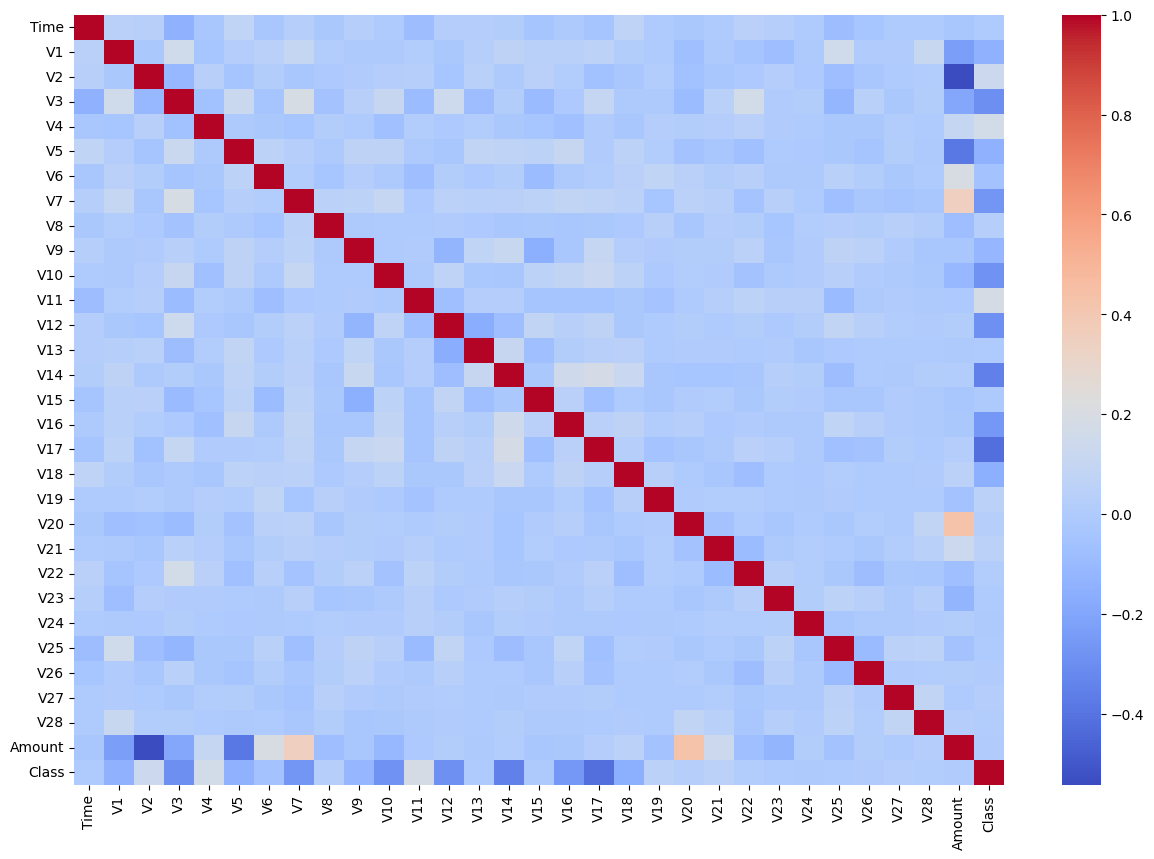

In [19]:
#Correlation Matrix
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

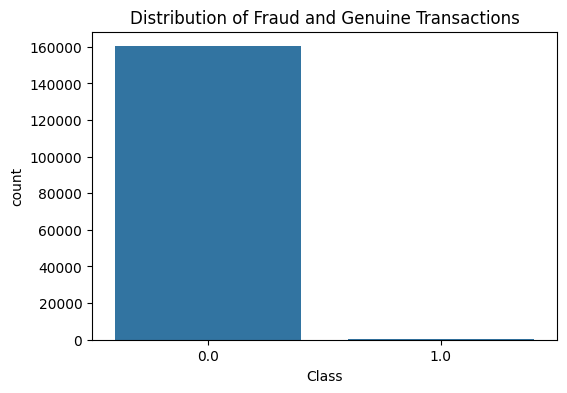

In [15]:
#Visualize Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)

plt.title("Distribution of Fraud and Genuine Transactions")
plt.show()

In [34]:
# Correlation Analysis
df.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.043812,0.033561,-0.149665,-0.024576,0.072524,-0.032067,0.027523,-0.018505,0.029658,...,-0.000362,0.042398,0.026723,-0.001347,-0.089259,-0.041547,-0.003088,-0.001309,-0.029908,-0.002890
V1,0.043812,1.000000,-0.019949,0.155006,-0.037607,0.019954,0.046725,0.099755,0.006157,-0.011297,...,-0.012067,-0.044665,-0.079553,-0.012123,0.151767,0.000038,0.001195,0.108923,-0.233758,-0.149441
V2,0.033561,-0.019949,1.000000,-0.113634,0.031848,-0.043765,0.012731,-0.029369,-0.015443,0.000208,...,-0.026798,-0.013883,0.022338,-0.015143,-0.079758,-0.027436,-0.000608,0.009401,-0.542488,0.127401
V3,-0.149665,0.155006,-0.113634,1.000000,-0.064683,0.123773,-0.047408,0.187592,-0.058616,0.034331,...,0.041811,0.163649,0.003861,0.013934,-0.126696,0.036597,-0.021919,0.017771,-0.198513,-0.298063
V4,-0.024576,-0.037607,0.031848,-0.064683,1.000000,-0.007866,-0.022587,-0.040453,0.016839,-0.001494,...,0.020217,0.042313,0.002975,-0.003228,-0.018872,-0.019582,0.007468,-0.005458,0.096609,0.165058
V5,0.072524,0.019954,-0.043765,0.123773,-0.007866,1.000000,0.054104,0.029178,-0.010755,0.063579,...,-0.031391,-0.070646,-0.000980,-0.013657,-0.023670,-0.043398,0.016022,-0.007877,-0.381035,-0.148224
V6,-0.032067,0.046725,0.012731,-0.047408,-0.022587,0.054104,1.000000,0.009434,-0.037055,0.021045,...,0.015971,0.035419,-0.011272,-0.007848,0.037866,0.013843,-0.021407,-0.005757,0.197205,-0.055167
V7,0.027523,0.099755,-0.029369,0.187592,-0.040453,0.029178,0.009434,1.000000,0.050499,0.058100,...,0.031495,-0.053718,0.034171,-0.000423,-0.074241,-0.027807,-0.045303,-0.028274,0.351163,-0.271037
V8,-0.018505,0.006157,-0.015443,-0.058616,0.016839,-0.010755,-0.037055,0.050499,1.000000,-0.011767,...,0.021844,0.017237,-0.036480,0.010000,0.018463,0.015364,0.031412,0.015280,-0.083049,0.028014
V9,0.029658,-0.011297,0.000208,0.034331,-0.001494,0.063579,0.021045,0.058100,-0.011767,1.000000,...,0.017000,0.053053,-0.029465,0.003964,0.060944,0.049436,0.003887,-0.025148,-0.034020,-0.117983


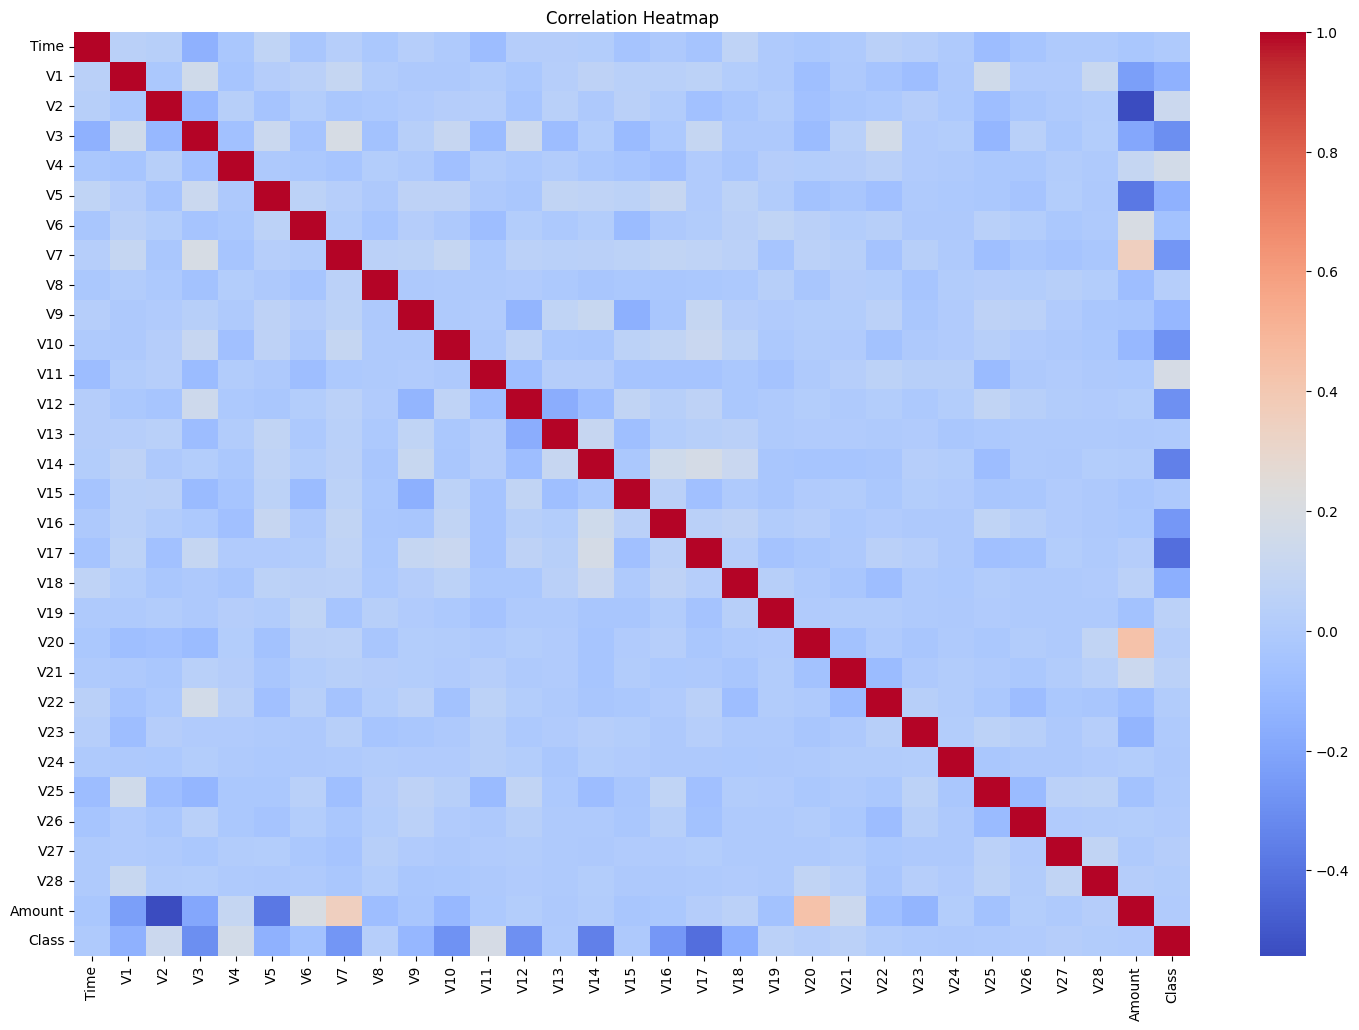

In [35]:
# Correlation Heatmap
plt.figure(figsize=(18,12))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [23]:
#Seperating Features and Target variable
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [24]:
# Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [27]:
#Split Dataset into Training and Testing set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
#Build Logistic Model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [32]:
#Make Predictions
y_pred = model.predict(X_test)

In [37]:
# Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9988479262672811

Confusion Matrix:
[[32031    12]
 [   25    48]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     32043
         1.0       0.80      0.66      0.72        73

    accuracy                           1.00     32116
   macro avg       0.90      0.83      0.86     32116
weighted avg       1.00      1.00      1.00     32116



In [38]:
# Model Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Accuracy Percentage :", accuracy*100)

Accuracy : 0.9988479262672811
Accuracy Percentage : 99.88479262672811


In [33]:
# Evaluate Model Performance
print("Accuracy :", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.9988479262672811
[[32031    12]
 [   25    48]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     32043
         1.0       0.80      0.66      0.72        73

    accuracy                           1.00     32116
   macro avg       0.90      0.83      0.86     32116
weighted avg       1.00      1.00      1.00     32116



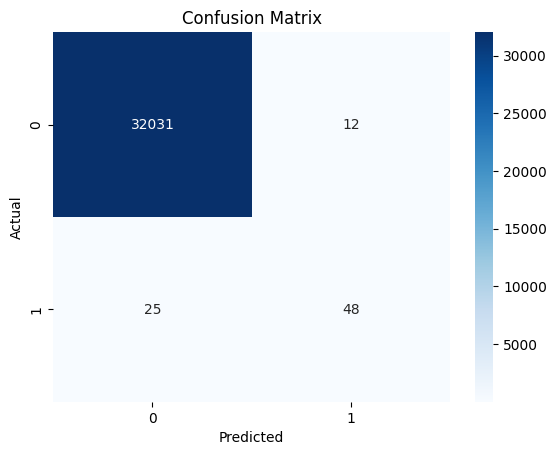

In [36]:
# Confusion Matrix Visualization
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d',
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [41]:
# Build Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [42]:
# Make Predictions using Decision Tree
dt_pred = dt_model.predict(X_test)

In [43]:
# Decision Tree Evaluation
print("Accuracy:", accuracy_score(y_test, dt_pred))

print(confusion_matrix(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Accuracy: 0.9990658861626603
[[32028    15]
 [   15    58]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     32043
         1.0       0.79      0.79      0.79        73

    accuracy                           1.00     32116
   macro avg       0.90      0.90      0.90     32116
weighted avg       1.00      1.00      1.00     32116



In [44]:
# Build Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
# Make Predictions using Random Forest
rf_pred = rf_model.predict(X_test)

In [46]:
# Random Forest Evaluation
print("Accuracy:", accuracy_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 0.9994706688255075
[[32041     2]
 [   15    58]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     32043
         1.0       0.97      0.79      0.87        73

    accuracy                           1.00     32116
   macro avg       0.98      0.90      0.94     32116
weighted avg       1.00      1.00      1.00     32116



In [47]:
# Model Comparison
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.998848
1,Decision Tree,0.999066
2,Random Forest,0.999471


In [48]:
# Best Model
comparison.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
2,Random Forest,0.999471
1,Decision Tree,0.999066
0,Logistic Regression,0.998848


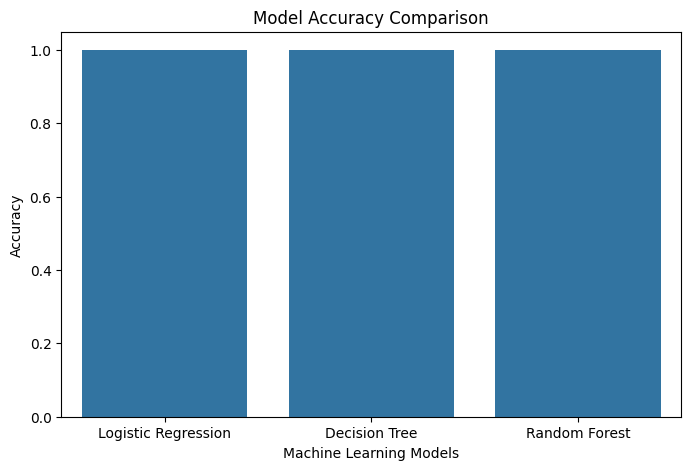

In [49]:
# Model Comparison Visualization
plt.figure(figsize=(8,5))

sns.barplot(x='Model', y='Accuracy', data=comparison)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.show()

In [50]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': df.columns[:-1],
    'Importance': rf_model.feature_importances_
})

feature_importance

,Feature,Importance
0,Time,0.009044
1,V1,0.013066
2,V2,0.011703
3,V3,0.019183
4,V4,0.032451
5,V5,0.011218
6,V6,0.013781
7,V7,0.013068
8,V8,0.008317
9,V9,0.038468


In [51]:
# Top Important Features
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
17,V17,0.180906
12,V12,0.132829
14,V14,0.122362
10,V10,0.092799
16,V16,0.080332
11,V11,0.048572
9,V9,0.038468
18,V18,0.032538
4,V4,0.032451
3,V3,0.019183


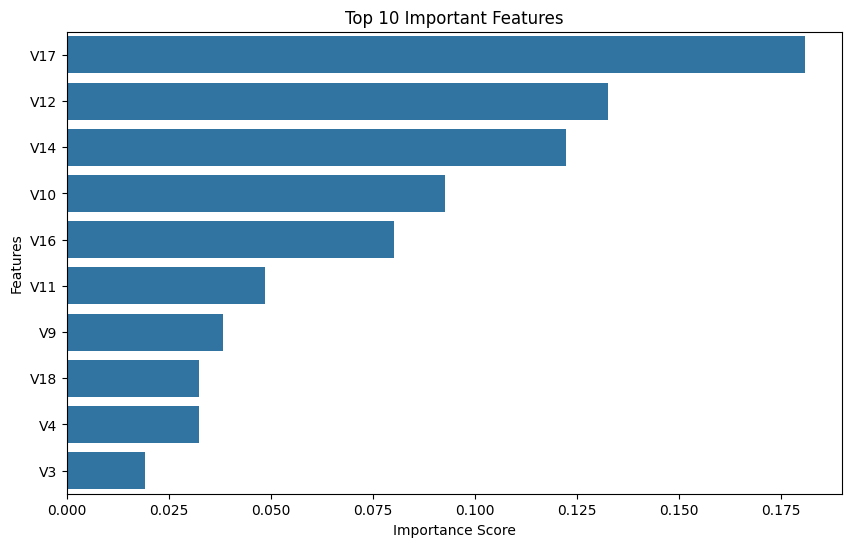

In [52]:
# Feature Importance Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# Conclusion
This project developed a machine learning system to detect fraudulent credit card transactions.

Three machine learning models—Logistic Regression, Decision Tree, and Random Forest—were trained and evaluated.

The models were compared using Accuracy, Confusion Matrix, Classification Report, and Feature Importance.

Among the tested models, Random Forest achieved the best performance for this dataset and was selected as the final model.


# Future Improvements
• Handle class imbalance using SMOTE.

• Perform Hyperparameter Tuning.

• Experiment with advanced algorithms such as XGBoost and LightGBM.


• Deploy the trained model as a web application using Streamlit.

• Evaluate the model using ROC-AUC and Precision-Recall Curve.